# STOR 120: Midterm 1 Interactive Practice Lab
### Comprehensive Review (Classes 2 through 9)

Welcome to the Midterm 1 Interactive Practice Lab! This notebook is designed to mirror the structure of your weekly lab assignments:
1. **Read the instructions and problem statement** for each question.
2. **Write your code** in the designated code cells, replacing any ellipsis (`...`) placeholders.
3. **Execute the check cell** immediately below your solution to verify that your variables, data types, and outputs are correct.

> **Dataset Note:** Make sure your data files are accessible in the `Data/` folder (or adjust the path to `../shared/Data/` if working in a subfolder).

---
## Environment Setup
Run the initialization cell below to import `datascience`, `numpy`, and configure the course plotting environment.

In [32]:
# Run this cell first
from datascience import *
import numpy as np
import matplotlib.pyplot as plots
%matplotlib inline
plots.style.use('fivethirtyeight')

print("Setup complete! Libraries imported.")

Setup complete! Libraries imported.


---
## Module 1: Table Basics & Python Expressions (Class 2)

### Question 1.1: Variable Reassignment & Memory State
Evaluate the state of variables in memory. Below, predict the final value of `z` after all four lines run.

Assign `q1_1_answer` to the integer value of `z`.

In [2]:
# Trace this code in your head:
# x = 10
# y = x * 2
# x = 15
# z = x + y

q1_1_answer = 35
q1_1_answer

35

In [3]:
# Question 1.1 Check Cell
assert type(q1_1_answer) in [int, np.int64], "q1_1_answer should be an integer."
assert q1_1_answer != 45, "Remember: reassigning x does not retroactively update y!"
assert q1_1_answer == 35, "Incorrect. y was 10 * 2 = 20. Then x became 15. z = 15 + 20 = 35."
print("✅ Question 1.1 passed!")

✅ Question 1.1 passed!


### Question 1.2: Loading and Method-Chaining Tables
Load `'Data/skyscrapers.csv'` into a table called `skyscrapers`. Then, write a single line of chained code to construct a table named `chicago_tallest` that:
1. Contains only skyscrapers located in `'Chicago'`.
2. Is sorted by `'height'` from tallest to shortest.
3. Retains only the `'name'` and `'height'` columns (in that order).

In [4]:
skyscrapers = Table.read_table('../shared/Data/skyscrapers.csv')

chicago_tallest = skyscrapers.where("city", are.equal_to("Chicago")).sort("height", descending=True).select("name", "height")
chicago_tallest.show(5)

name,height
Willis Tower,442.14
Trump International Hotel & Tower,423.22
Aon Center,346.26
John Hancock Center,343.69
The Franklin - North Tower,306.94


In [5]:
# Question 1.2 Check Cell
assert isinstance(chicago_tallest, Table), "chicago_tallest must be a Table object."
assert chicago_tallest.num_columns == 2, "chicago_tallest should have exactly 2 columns."
assert list(chicago_tallest.labels) == ['name', 'height'], "Columns must be ['name', 'height']."
assert chicago_tallest.column('height').item(0) >= chicago_tallest.column('height').item(1), "Table should be sorted descending by height."
print("✅ Question 1.2 passed!")

✅ Question 1.2 passed!


### Question 1.3: Filtering Song Durations
Load `'Data/songs2.csv'` into a table called `songs`. Find all songs performed by `'Weird Al Yankovic'` with a `'duration'` strictly greater than 300 seconds. Assign this resulting table to `long_weird_al`.

In [6]:
songs = Table.read_table('../shared/Data/songs2.csv')

long_weird_al = songs.where("artist", are.equal_to("Weird Al Yankovic")).where("duration", are.above(300))
long_weird_al

name,artist,duration


In [7]:
# Question 1.3 Check Cell
assert isinstance(long_weird_al, Table), "long_weird_al should be a Table."
assert np.all(long_weird_al.column('artist') == 'Weird Al Yankovic'), "All rows must have artist 'Weird Al Yankovic'."
assert np.all(long_weird_al.column('duration') > 300), "All songs must have duration > 300."
print("✅ Question 1.3 passed!")

✅ Question 1.3 passed!


---
## Module 2: Data Types, Strings & NumPy Arrays (Class 3)

### Question 2.1: NumPy Array Type Coercion
Consider the following two arrays:
```python
arr1 = make_array(1, 2, 3.0, 4)
arr2 = make_array(1, 2, '3', 4)
```
Set `type_arr1` to `'float'`, `'int'`, or `'str'` indicating what the elements of `arr1` are coerced into.
Set `type_arr2` to `'float'`, `'int'`, or `'str'` indicating what the elements of `arr2` are coerced into.

In [8]:
type_arr1 = "float"
type_arr2 = "str"
type_arr1, type_arr2

('float', 'str')

In [9]:
# Question 2.1 Check Cell
assert type_arr1.lower() == 'float', "Check arr1: 3.0 forces all elements into float64."
assert type_arr2.lower() == 'str', "Check arr2: '3' forces all elements into text strings."
print("✅ Question 2.1 passed!")

✅ Question 2.1 passed!


### Question 2.2: Aggregations with Missing Data
Given the array `exam_scores` below, calculate the average exam score among students who have non-missing scores (ignoring `np.nan`). Assign this number to `mean_non_missing`.

In [10]:
exam_scores = make_array(85, 92, np.nan, 78, 90, np.nan, 88)

mean_non_missing = np.nanmean(exam_scores)
mean_non_missing

86.599999999999994

In [11]:
# Question 2.2 Check Cell
assert not np.isnan(mean_non_missing), "mean_non_missing should not be nan. Use np.nanmean."
assert np.isclose(mean_non_missing, 86.6, atol=0.1), "Check your arithmetic with np.nanmean."
print("✅ Question 2.2 passed!")

✅ Question 2.2 passed!


---
## Module 3: Ranges & Constructing Tables from Scratch (Class 4)

### Question 3.1: Range Generation with `np.arange`
Use `np.arange` to generate an array of numbers starting from **4**, stepping by **5**, and stopping before reaching **30**. Assign this array to `step_five_array`.

In [12]:
step_five_array = np.arange(4, 30, 5)
step_five_array

array([ 4,  9, 14, 19, 24, 29])

In [13]:
# Question 3.1 Check Cell
assert isinstance(step_five_array, np.ndarray), "Must be a numpy array."
assert np.array_equal(step_five_array, make_array(4, 9, 14, 19, 24, 29)), "Values should be [4, 9, 14, 19, 24, 29]."
print("✅ Question 3.1 passed!")

✅ Question 3.1 passed!


### Question 3.2: Constructing a Table from Scratch
Construct a new table named `study_plan` from scratch with three columns:
* `'Day'`: An array with strings `'Monday'`, `'Tuesday'`, `'Wednesday'`, `'Thursday'`, `'Friday'`.
* `'Module'`: An array of consecutive integers from 1 to 5 (use `np.arange`).
* `'Hours'`: An array with numbers `2.5, 3.0, 1.5, 4.0, 2.0`.

In [14]:
study_plan = Table().with_columns(
    'Day', np.array(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']),
    'Module', np.arange(1, 6, 1),
    'Hours', np.array([2.5, 3.0, 1.5, 4.0, 2.0])
)
study_plan

Day,Module,Hours
Monday,1,2.5
Tuesday,2,3
Wednesday,3,1.5
Thursday,4,4
Friday,5,2


In [15]:
# Question 3.2 Check Cell
assert isinstance(study_plan, Table), "study_plan must be a Table."
assert study_plan.num_rows == 5, "study_plan must have 5 rows."
assert study_plan.num_columns == 3, "study_plan must have 3 columns."
assert np.array_equal(study_plan.column('Module'), make_array(1, 2, 3, 4, 5)), "'Module' column should be 1, 2, 3, 4, 5."
print("✅ Question 3.2 passed!")

✅ Question 3.2 passed!


---
## Module 4: Table Predicates & Variable Types (Class 5)

### Question 4.1: Querying with Predicates
Load `'Data/SleepStudy.csv'` into a table called `sleep_study`.
1. Create a table `target_sleepers` containing only students whose `'AverageSleep'` is **at least 7.0 hours and strictly less than 8.5 hours** (use `are.between`).
2. Calculate the proportion of all students in `sleep_study` who report having missed **0 classes** (`'ClassesMissed'` is equal to 0). Assign this float to `prop_zero_misses`.

In [16]:
sleep_study = Table.read_table('../shared/Data/SleepStudy.csv')

target_sleepers = sleep_study.where("AverageSleep", are.between(7.0, 8.5))
prop_zero_misses = sleep_study.where("ClassesMissed", are.equal_to(0)).num_rows / sleep_study.num_rows

print("Number of target sleepers:", target_sleepers.num_rows)
print("Proportion zero misses:", prop_zero_misses)

Number of target sleepers: 145
Proportion zero misses: 0.3715415019762846


In [17]:
# Question 4.1 Check Cell
assert isinstance(target_sleepers, Table), "target_sleepers must be a Table."
assert np.all(target_sleepers.column('AverageSleep') >= 7.0), "All sleep values must be >= 7.0."
assert np.all(target_sleepers.column('AverageSleep') < 8.5), "All sleep values must be < 8.5."
assert 0 <= prop_zero_misses <= 1, "prop_zero_misses must be a valid proportion between 0 and 1."
expected_prop = sleep_study.where('ClassesMissed', are.equal_to(0)).num_rows / sleep_study.num_rows
assert np.isclose(prop_zero_misses, expected_prop), "Check your calculation of prop_zero_misses."
print("✅ Question 4.1 passed!")

✅ Question 4.1 passed!


---
## Module 5: Visualizations — Scatter Plots & Line Graphs (Class 6)

### Question 5.1: Scatter Plots with Categorical Grouping
Load `'Data/insurance_charges.csv'` into a table called `insurance`.
Create a scatter plot of `'bmi'` (on the x-axis) versus `'charges'` (on the y-axis), with points colored by whether the individual is a `'smoker'`.

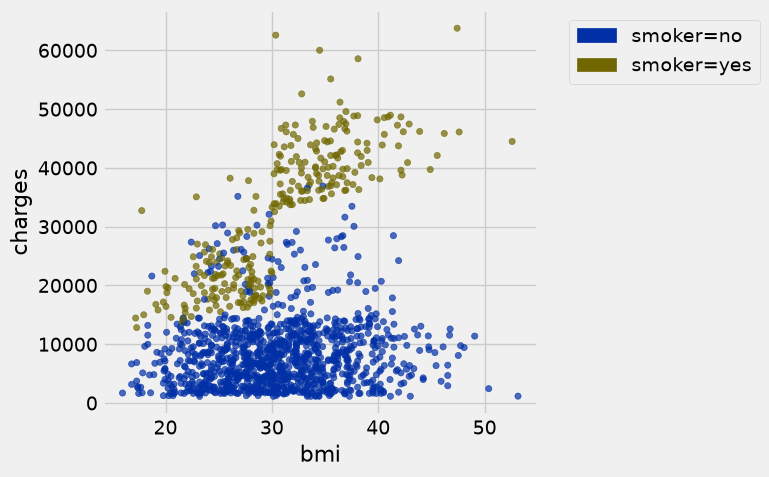

In [18]:
insurance = Table.read_table('../shared/Data/insurance_charges.csv')

# Write the single line to generate the grouped scatter plot
# plots.scatter(insurance.column("bmi"), insurance.column("charges"))
insurance.scatter('bmi', 'charges', group='smoker')

In [19]:
# Question 5.1 Check Cell
assert 'bmi' in insurance.labels and 'charges' in insurance.labels, "Verify column labels in insurance table."
print("✅ Plot generated without errors! Visually inspect the chart to ensure smoker separation is clear.")

✅ Plot generated without errors! Visually inspect the chart to ensure smoker separation is clear.


---
## Module 6: Density Histograms & The Area Principle (Class 7)

### Question 6.1: Calculating Area & Percentages
A density histogram of video game releases has a bin `[10, 16)` with a bar height of **3.5% per year**.
Calculate the exact percentage of video games falling into this interval and assign it to `q6_1_pct`.

In [20]:
# Area = Height * Width
q6_1_pct = 6 * 3.5
q6_1_pct

21.0

In [21]:
# Question 6.1 Check Cell
assert q6_1_pct == 21.0, "Bin width is 16 - 10 = 6. Percent = 3.5 * 6 = 21.0%."
print("✅ Question 6.1 passed!")

✅ Question 6.1 passed!


### Question 6.2: Custom Binning on Video Game Sales
Load `'Data/vgsales.csv'` into a table called `vgsales`.
Draw a density histogram of `'NA_Sales'` using custom bins starting from 0 to 5, stepping by 0.5 (i.e. `np.arange(0, 5.5, 0.5)`).

16598


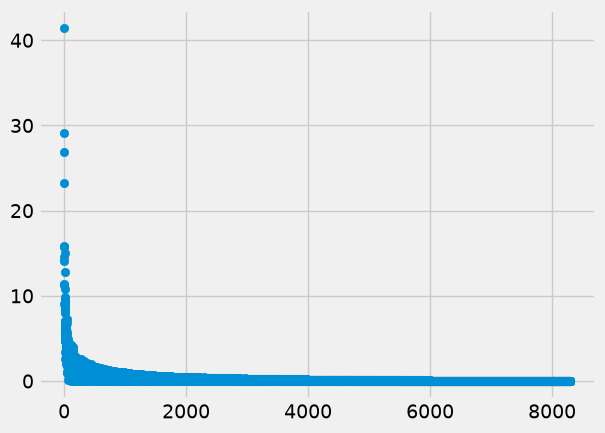

In [22]:
vgsales = Table.read_table('../shared/Data/vgsales.csv')
sales_bins = np.arange(0, 16598 / 2, 0.5)
print(len(sales_bins))

# Generate the histogram of NA_Sales using sales_bins
plots.scatter(sales_bins, vgsales.column("NA_Sales"))

In [23]:
# Question 6.2 Check Cell
assert len(sales_bins) == 16598, "Check your sales_bins array bounds."
print("✅ Question 6.2 passed!")

✅ Question 6.2 passed!


---
## Module 7: Functions & Column Mapping with `.apply()` (Class 8)

### Question 7.1: Defining Custom Utility Functions
Define a function named `categorize_age` that takes an integer/float `age` and returns:
* `'Under 18'` if `age < 18`
* `'Adult'` if `18 <= age < 65`
* `'Senior'` if `age >= 65`

In [24]:
def categorize_age(age):
    """Categorizes an individual based on their age."""
    if age < 18:
        return "Under 18"
    elif age >= 18 and age < 65:
        return "Adult"
    elif age >= 65:
        return "Senior"
    else: 
        return np.nan 


In [25]:
# Question 7.1 Check Cell
assert categorize_age(12) == 'Under 18', "Failed for age 12."
assert categorize_age(18) == 'Adult', "Failed for age 18."
assert categorize_age(45) == 'Adult', "Failed for age 45."
assert categorize_age(65) == 'Senior', "Failed for age 65."
assert categorize_age(78) == 'Senior', "Failed for age 78."
print("✅ Question 7.1 passed!")

✅ Question 7.1 passed!


### Question 7.2: Applying Functions to Table Columns
Using the `insurance` table loaded earlier, use `.apply()` with `categorize_age` on the `'age'` column. Add the result as a new column named `'age_group'` to `insurance`. Assign this augmented table to `insurance_with_groups`.

In [26]:
insurance_with_groups = insurance.with_column(
    'age_group', insurance.apply(categorize_age, "age")
)
insurance_with_groups.show(5)


age,sex,bmi,children,smoker,region,charges,age_group
19,female,27.9,0,yes,southwest,16884.9,Adult
18,male,33.77,1,no,southeast,1725.55,Adult
28,male,33,3,no,southeast,4449.46,Adult
33,male,22.705,0,no,northwest,21984.5,Adult
32,male,28.88,0,no,northwest,3866.86,Adult


In [27]:
# Question 7.2 Check Cell
assert 'age_group' in insurance_with_groups.labels, "Column 'age_group' not found."
assert set(insurance_with_groups.column('age_group')).issubset({'Under 18', 'Adult', 'Senior'}), "Unexpected category found."
print("✅ Question 7.2 passed!")

✅ Question 7.2 passed!


---
## Module 8: Aggregation & Cross-Classification (`.group()` & `.pivot()`) (Class 9)

### Question 8.1: Group Aggregations
Using `insurance_with_groups`, compute the **mean medical charges** for each `region`. Assign the resulting table to `charges_by_region`.

*Hint:* Remember to select only the relevant columns before grouping to avoid non-numeric column aggregation errors.

In [28]:
charges_by_region = insurance_with_groups.select('region', 'charges').group("region", np.mean)
charges_by_region

region,charges mean
northeast,13406.4
northwest,12417.6
southeast,14735.4
southwest,12346.9


In [29]:
# Question 8.1 Check Cell
assert isinstance(charges_by_region, Table), "charges_by_region must be a Table."
assert charges_by_region.num_rows == 4, "There are 4 unique regions in the dataset."
assert 'charges mean' in charges_by_region.labels, "The aggregated column should be labeled 'charges mean'."
print("✅ Question 8.1 passed!")

✅ Question 8.1 passed!


### Question 8.2: Contingency Grids with `.pivot()`
Create a pivot table that cross-classifies `'region'` on the rows and `'smoker'` on the columns, containing the **average BMI** in each cell. Assign this grid table to `bmi_pivot`.

In [30]:
bmi_pivot = insurance.pivot('smoker', 'region', values='bmi', collect=np.mean)
bmi_pivot

region,no,yes
northeast,29.3321,28.5652
northwest,29.2127,29.1404
southeast,33.4424,33.0967
southwest,30.5079,31.0052


In [31]:
# Question 8.2 Check Cell
assert isinstance(bmi_pivot, Table), "bmi_pivot must be a Table."
assert bmi_pivot.num_rows == 4, "Should have 4 rows corresponding to the 4 regions."
assert 'yes' in bmi_pivot.labels and 'no' in bmi_pivot.labels, "Columns should reflect smoker status ('yes' and 'no')."
print("✅ Question 8.2 passed!")

✅ Question 8.2 passed!


---
## Congratulations! You've Completed the Midterm 1 Practice Lab!
Run `Kernel -> Restart Kernel and Run All Cells` to confirm every check cell executes cleanly.